# Exposure export

Exporting flood exposure data to CSV for sharing

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [41]:
import pandas as pd

from src.utils import db_utils, blob_utils

In [3]:
pcode = "SS"
query = f"SELECT * FROM app.floodscan_exposure WHERE pcode = '{pcode}'"

In [4]:
query

"SELECT * FROM app.floodscan_exposure WHERE pcode = 'SS'"

In [35]:
df_exp = pd.read_sql(query, db_utils.get_engine(), parse_dates=["valid_date"])
df_exp["sum"] = df_exp["sum"].astype(int)

In [36]:
df_exp.dtypes

iso3                  object
adm_level             object
valid_date    datetime64[ns]
pcode                 object
sum                    int64
dtype: object

In [37]:
df_exp["doy"] = df_exp["valid_date"].dt.dayofyear
df_exp["year"] = df_exp["valid_date"].dt.year
df_exp["date_1900"] = pd.to_datetime(df_exp["doy"], format="%j")

In [38]:
df_exp

,iso3,adm_level,valid_date,pcode,sum,doy,year,date_1900
0,SSD,0,2025-01-01,SS,303159,1,2025,1900-01-01
1,SSD,0,2025-01-02,SS,293462,2,2025,1900-01-02
2,SSD,0,2025-01-03,SS,284283,3,2025,1900-01-03
3,SSD,0,2025-01-04,SS,279562,4,2025,1900-01-04
4,SSD,0,2025-01-05,SS,260847,5,2025,1900-01-05
...,...,...,...,...,...,...,...,...
9913,SSD,0,2025-03-04,SS,206998,63,2025,1900-03-04
9914,SSD,0,2025-03-05,SS,209206,64,2025,1900-03-05
9915,SSD,0,2025-03-06,SS,210096,65,2025,1900-03-06
9916,SSD,0,2025-03-07,SS,221344,66,2025,1900-03-07


<Axes: xlabel='date_1900'>

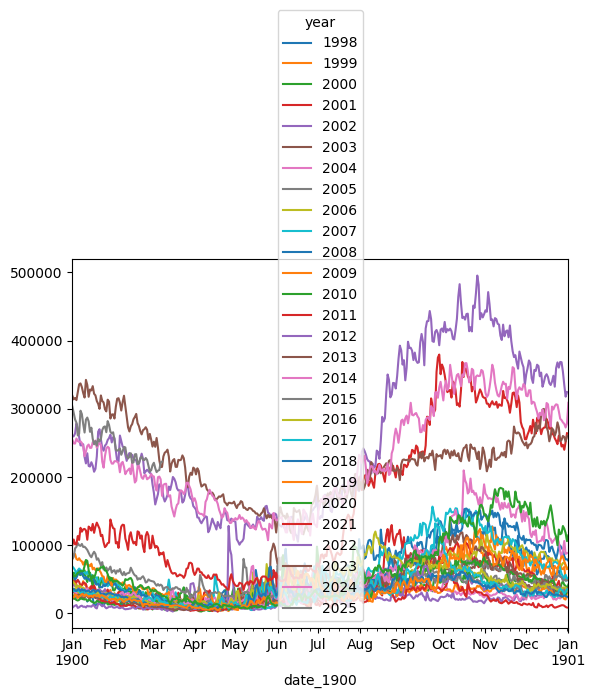

In [44]:
df_exp.pivot(index="date_1900", columns="year", values="sum").plot()

In [47]:
import src.constants

blob_name = f"{src.constants.PROJECT_PREFIX}/processed/floodscan/{pcode}_flood_exposure.csv"
blob_utils.upload_csv_to_blob(df_exp, blob_name)